In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\ADITYA GUPTA\Downloads\Netflix Dataset\Netflix Datasets Evaluation MS Excel.csv")

In [3]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,date_added.1,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,25-09-2021,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,24-09-2021,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [4]:
df[['date_added']].head(20)

,date_added
0,25-Sep-21
1,24-Sep-21
2,24-Sep-21
3,24-Sep-21
4,24-Sep-21
5,24-Sep-21
6,24-Sep-21
7,24-Sep-21
8,24-Sep-21
9,24-Sep-21


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   date_added.1  8797 non-null   str  
 8   release_year  8807 non-null   int64
 9   rating        8803 non-null   str  
 10  duration      8804 non-null   str  
 11  listed_in     8807 non-null   str  
 12  description   8807 non-null   str  
dtypes: int64(1), str(12)
memory usage: 894.6 KB


In [6]:
df.shape

(8807, 13)

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
date_added.1      10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna('other')
df['country'] = df['country'].fillna('other')
df['rating'] = df['rating'].fillna('None')
df['duration'] = df['duration'].fillna('Not Available')

In [9]:
df = df.drop('date_added.1', axis=1)

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'])

C:\Users\ADITYA GUPTA\AppData\Local\Temp\ipykernel_1308\2944776423.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'])


In [11]:
df['date_added'] = df['date_added'].interpolate()

In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [13]:
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [14]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,other,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8807 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


# Page-1
# Donut chart → Movies vs TV Shows

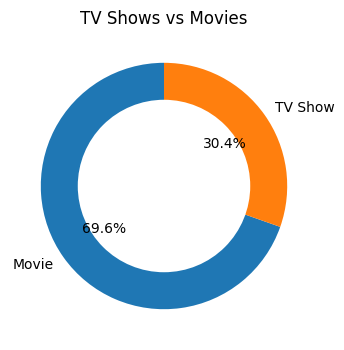

In [17]:
# Count the values
counts = df['type'].value_counts()

# Create donut chart
plt.figure(figsize=(6, 4))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, fc='white'))
plt.title('TV Shows vs Movies')
plt.show()

In [18]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,other,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


# Bar chart → Top 10 countries

In [19]:
df[['country']].value_counts().head(10)

country       
United States     2818
India              972
other              831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

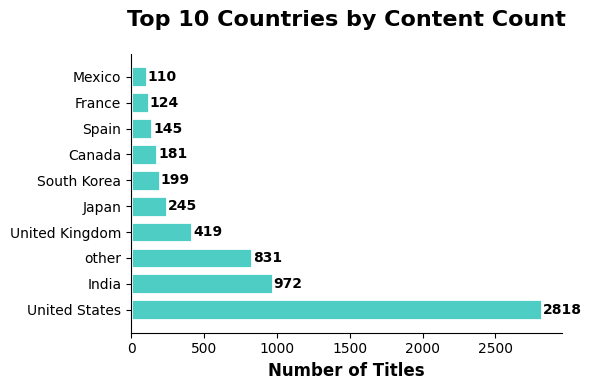

In [20]:
# Get top 10 countries (assuming you have a 'country' column)
top_countries = df['country'].value_counts().head(10)

# Create bar chart
fig, ax = plt.subplots(figsize=(6, 4))

# Create horizontal bar chart (easier to read country names)
bars = ax.barh(range(len(top_countries)), top_countries.values, color='#4ECDC4', edgecolor='white', linewidth=2)

# Customize
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index)
ax.set_xlabel('Number of Titles', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Countries by Content Count', fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_countries.values)):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Line chart → Releases per year (split by type)

In [21]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,other,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [22]:
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

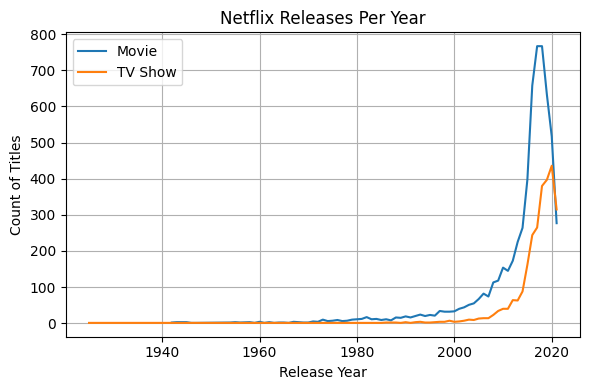

In [23]:
grouped = df.groupby(['release_year', 'type']).size().reset_index(name='count')

movies = grouped[grouped['type'] == 'Movie']
tvshows = grouped[grouped['type'] == 'TV Show']

plt.figure(figsize=(6, 4))

plt.plot(movies['release_year'], movies['count'], label='Movie')
plt.plot(tvshows['release_year'], tvshows['count'], label='TV Show')

plt.title('Netflix Releases Per Year')
plt.xlabel('Release Year')
plt.ylabel('Count of Titles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Some KPI

In [24]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,other,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [25]:
total_title = df['title'].count()
print(total_title)

8807


In [26]:
total_movies = df[df['type'] == 'Movie'].shape[0]
print(total_movies)

6131


In [27]:
Total_TV_Shows = df[df['type'] == 'TV Show'].shape[0]
print(Total_TV_Shows)

2676


In [28]:
movie_per = (df['type'] == 'Movie').mean() * 100
print(movie_per)

69.61507891449983
